# Start with something simple

## Test what we think ?

255 0


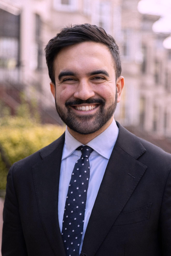

In [ ]:
from PIL import Image
import numpy as np
import requests
from io import BytesIO

url = "https://m.media-amazon.com/images/M/MV5BYjUxYzdjZmItY2M2YS00OTQ1LTkwNDktNmExOWJlMTYwZTM0XkEyXkFqcGc@._V1_.jpg"
headers = {
    "User-Agent": "Mozilla/5.0",
}

try:
    response = requests.get(url, headers=headers)
    response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    img.thumbnail((256, 256))
    arr = np.array(img)
    print(arr.max(), arr.min())
    display(img)
except requests.exceptions.HTTPError as e:
    print(f"An HTTP error occurred: {e}. Please try again later or use a different image URL.")
    img = None
    arr = None
except requests.exceptions.RequestException as e:
    print(f"A network error occurred: {e}. Please check your internet connection.")
    img = None
    arr = None


(256, 171, 3)
111.02290448343079 6060.248074312513
0.0001370482403682735 1.0014150263798014


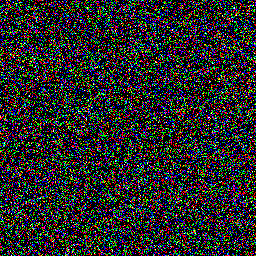

In [ ]:
img = np.array(img)
print(img.shape)
print(img.mean(), img.var())

gaaussian = np.random.normal(0, 1, size=(256, 256, 3))
print(gaaussian.mean(), gaaussian.var())


out = Image.fromarray(gaaussian.astype('uint8'))
out

255 0 111.02290448343079 6060.248074312513
265.541221407377 -9.399083804066752 111.00938500920269 6070.34785332966


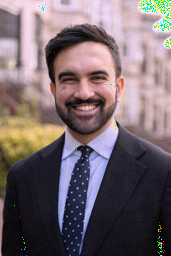

In [ ]:
out = arr.copy()
print(out.max(), out.min(), out.mean(), out.var())
# gaaussian = np.random.normal(0, 1, size=(1, *arr.shape))
gaaussian = np.random.normal(0, 1, size=(10, *arr.shape))
# gaaussian = np.random.normal(0, 1, size=(100, *arr.shape))
# gaaussian = np.random.normal(0, 1, size=(1000, *arr.shape))
# gaaussian = np.random.normal(0, 1, size=(5000, *arr.shape))
# gaaussian = np.random.normal(0, 1, size=(10_000, *arr.shape))
# gaaussian = np.random.normal(0, 1, size=(100_000, *arr.shape))
out = out + gaaussian.sum(axis=0)
print(out.max(), out.min(), out.mean(), out.var())
out = Image.fromarray(out.astype('uint8'))
display(out)

In [ ]:
out = arr.copy()
print(out.max(), out.min(), out.mean(), out.var())
for i in range(100):
  gaaussian = np.random.normal(0, 1, size=(1, *arr.shape))
  out = out + gaaussian.sum(axis=0)
  out = out.astype('uint8')
print(np.array(out).max(), np.array(out).min(), np.array(out).mean(), np.array(out).var())
out = Image.fromarray(out)
out

602.5169425144402 -426.7362958558342 110.9594819566085 16123.616421418137


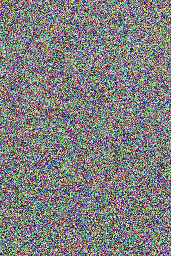

In [ ]:
out = arr.copy()
# gaaussian = 1*np.random.normal(0, 1, size=(1, *arr.shape))
# gaaussian = 10*np.random.normal(0, 1, size=(1, *arr.shape))
gaaussian = 100*np.random.normal(0, 1, size=(1, *arr.shape))
# gaaussian = 1000*np.random.normal(0, 1, size=(1, *arr.shape))
out = out + gaaussian.sum(axis=0)
print(np.array(out).max(), np.array(out).min(), np.array(out).mean(), np.array(out).var())
out = Image.fromarray(out.astype('uint8'))
out

# Welcome to the world of schedulers

## First schedular formula

$$x_t = \sqrt{1-\beta_t}x_{t-1} + \sqrt{\beta_t}\eta_t$$

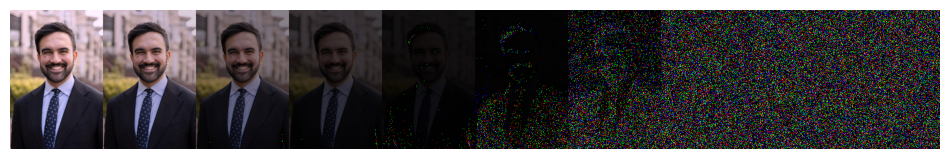

In [ ]:
import matplotlib.pyplot as plt

out = arr.copy()
beta = np.linspace(0.0001, 0.2, num=300)
plot_every = 30

outputs = []
for idx, s in enumerate(beta):
    gaussian = np.random.normal(0, 1, arr.shape)
    # step 1: out = x_0
    out = np.sqrt(1-s)*out + np.sqrt(s)*gaussian
    if idx % plot_every == 0:
        outputs.append(Image.fromarray(out.astype('uint8')))

combined = np.hstack(outputs)

plt.figure(figsize=(12, 4))
plt.imshow(combined)
plt.axis("off")
plt.show()

## Better one step formula for x_t from x_0

$$x_t = \sqrt{\bar{\alpha_t}}x_0 + \sqrt{1-\bar{\alpha_t}}\eta_t$$

where
$$ \bar{\alpha_t} = \prod_{i=1}^t{1-\beta_i} $$

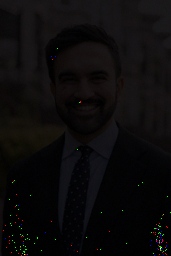

In [ ]:
out = arr.copy()
beta = np.linspace(0.001, 1, num=300)
alpha = [np.prod(1 - beta[:i+1]) for i in range(beta.shape[0])]
def get_corrupted_image(index):
  return np.sqrt(alpha[index])*out + np.sqrt(1-alpha[index])*np.random.normal(0, 1, arr.shape)

Image.fromarray(get_corrupted_image(50).astype('uint8'))

# Let's train a Diffusion model

In [ ]:
!pip install -q datasets torchvision torchmetrics[image]

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from datasets import load_dataset
from torchvision import transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from torchmetrics.image.fid import FrechetInceptionDistance
from IPython.display import display, clear_output

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.5 MB/s eta 0:00:00


## Dataset Preparing

In [ ]:
# Dataset processing

IMAGE_SIZE = 32
BATCH_SIZE = 64

preprocess = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]) # Scale pixels to [-1, 1]
])

print("Loading and preprocessing dataset...")
raw_dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

# Convert all images directly to a PyTorch tensor (takes ~2 seconds)
images = torch.stack([preprocess(img.convert("RGB")) for img in raw_dataset["image"]])
dataset = torch.utils.data.TensorDataset(images)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Dataset ready: {len(dataset)} images loaded into tensor shape {images.shape}.")


Loading and preprocessing dataset...


README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.65k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  237MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset ready: 1000 images loaded into tensor shape torch.Size([1000, 3, 32, 32]).


## Model Definitions

### Simple DiT

In [ ]:
class PositionEmbedding2D(nn.Module):
    def __init__(self, d_model: int, grid_size: int):
        super().__init__()
        assert d_model % 4 == 0, "d_model must be divisible by 4 for 2D sin-cos embedding"
        half_dim = d_model // 4

        # 1. Frequency exponential scale
        freqs = 1.0 / (10000 ** (torch.arange(0, half_dim, dtype=torch.float32) / half_dim))

        # 2. 2D Coordinate Grid
        grid_h = torch.arange(grid_size, dtype=torch.float32)
        grid_w = torch.arange(grid_size, dtype=torch.float32)
        grid = torch.meshgrid(grid_h, grid_w, indexing="ij")

        # 3. Outer product -> (N, half_dim)
        emb_h = grid[0].flatten()[:, None] * freqs[None, :]
        emb_w = grid[1].flatten()[:, None] * freqs[None, :]

        # 4. Concatenate sin/cos for H and W -> (1, N, d_model)
        pos_embed = torch.cat([
            torch.sin(emb_h), torch.cos(emb_h),
            torch.sin(emb_w), torch.cos(emb_w)
        ], dim=-1).unsqueeze(0)

        # Register buffer inside this submodule
        self.register_buffer("pos_embed", pos_embed, persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x shape: (B, N, d_model)
        Returns: (B, N, d_model) with positional embeddings added
        """
        return x + self.pos_embed

class GaussianFourierEmbedding(nn.Module):
    def __init__(self, dim: int, scale: float = 16.0):
        super().__init__()
        assert dim % 2 == 0, "Embedding dimension must be even"

        half_dim = dim // 2
        # Random Gaussian frequencies W ~ N(0, scale^2)
        # Frozen (requires_grad=False) as per Fourier Feature theory (Tancik et al.)
        self.W = nn.Parameter(torch.randn(half_dim) * scale, requires_grad=False)

        # MLP to process raw Fourier features
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, dim)
        )

    def forward(self, t: torch.Tensor, max_timesteps: float = 1000.0):
        # 1. Normalize t to [0, 1] range for numerical stability across schedules
        t_norm = t.float() / max_timesteps

        # 2. Compute 2 * pi * t * W
        # t_norm shape: (B, 1), W shape: (1, half_dim) -> Outer product (B, half_dim)
        t_proj = t_norm[:, None] * self.W[None, :] * 2 * math.pi

        # 3. Concatenate Sine and Cosine projections -> shape (B, dim)
        fourier_features = torch.cat([torch.sin(t_proj), torch.cos(t_proj)], dim=-1)

        # 4. Map through MLP
        return self.mlp(fourier_features)

class ButterFlyDiT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, d_model=256, nhead=4, num_layers=4):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        grid_size = img_size // patch_size
        patch_dim = in_channels * patch_size * patch_size

        # Patch Embedding & Position Embedding
        self.patch_embed = nn.Linear(patch_dim, d_model)
        self.pos_embed = PositionEmbedding2D(d_model, grid_size)

        # Timestep Embedding
        self.time_embed = nn.Sequential(
            GaussianFourierEmbedding(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model)
        )

        # Transformer Encoder Blocks
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*2, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Output projection back to patch dimension
        self.unpatch_embed = nn.Linear(d_model, patch_dim)

    def patchify(self, x):
        # x: (B, C, H, W) -> (B, N, patch_dim)
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 3, 5, 1).reshape(B, -1, p * p * C)
        return x

    def unpatchify(self, x, H=32, W=32):
        # x: (B, N, patch_dim) -> (B, C, H, W)
        B, N, _ = x.shape
        p = self.patch_size
        x = x.reshape(B, H // p, W // p, p, p, 3)
        x = x.permute(0, 5, 1, 3, 2, 4).reshape(B, 3, H, W)
        return x

    def forward(self, x, t):
        B = x.shape[0]
        tokens = self.patchify(x)                 # Step 1: Patchify
        tokens = self.patch_embed(tokens)         # Project + Add Pos Embed
        tokens = self.pos_embed(tokens)

        # Prefix time token
        t_emb = self.time_embed(t).unsqueeze(1)   # Embed Timestep
        tokens = torch.cat([t_emb, tokens], dim=1)  # Inject Timestep into Tokens

        out = self.transformer(tokens)[:, 1:, :]  # Step 2: Transformer Blocks
        out = self.unpatch_embed(out)             # Step 3: Unpatchify Linear
        return self.unpatchify(out, x.shape[2], x.shape[3])


### GQA DiT

In [ ]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, num_groups: int):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        assert num_heads % num_groups == 0, "num_heads must be divisible by num_groups"

        self.d_model = d_model
        self.num_heads = num_heads
        self.num_groups = num_groups
        self.head_dim = d_model // num_heads
        self.num_queries_per_group = num_heads // num_groups

        # Q projects to full num_heads, while K and V project to num_groups
        self.q_proj = nn.Linear(d_model, num_heads * self.head_dim, bias=False)
        self.k_proj = nn.Linear(d_model, num_groups * self.head_dim, bias=False)
        self.v_proj = nn.Linear(d_model, num_groups * self.head_dim, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, N, C = x.shape

        # 1. Linear Projections
        q = self.q_proj(x).view(B, N, self.num_heads, self.head_dim).transpose(1, 2)  # (B, num_heads, N, head_dim)
        k = self.k_proj(x).view(B, N, self.num_groups, self.head_dim).transpose(1, 2) # (B, num_groups, N, head_dim)
        v = self.v_proj(x).view(B, N, self.num_groups, self.head_dim).transpose(1, 2) # (B, num_groups, N, head_dim)

        # 2. Expand K and V heads across query groups
        if self.num_queries_per_group > 1:
            k = k.repeat_interleave(self.num_queries_per_group, dim=1) # (B, num_heads, N, head_dim)
            v = v.repeat_interleave(self.num_queries_per_group, dim=1) # (B, num_heads, N, head_dim)

        # 3. Fast Scaled Dot-Product Attention (PyTorch 2.0+ optimized)
        out = F.scaled_dot_product_attention(q, k, v) # (B, num_heads, N, head_dim)

        # 4. Reshape and project back to d_model
        out = out.transpose(1, 2).contiguous().view(B, N, C)
        return self.out_proj(out)


class GQATransformerBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, num_groups: int, dim_feedforward: int = None):
        super().__init__()
        if dim_feedforward is None:
            dim_feedforward = d_model * 2

        self.norm1 = nn.LayerNorm(d_model)
        self.attn = GroupedQueryAttention(d_model=d_model, num_heads=num_heads, num_groups=num_groups)

        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Linear(dim_feedforward, d_model)
        )

    def forward(self, x):
        # Pre-LN Transformer Block
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class ButterFlyDiT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, d_model=256, nhead=4, num_groups=2, num_layers=6):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = in_channels * patch_size * patch_size

        # Patch Embedding & Position Embedding
        self.patch_embed = nn.Linear(patch_dim, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, d_model))

        # Timestep Embedding
        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbeddings(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model)
        )

        # GQA Transformer Encoder Stack
        self.transformer_blocks = nn.ModuleList([
            GQATransformerBlock(
                d_model=d_model,
                num_heads=nhead,
                num_groups=num_groups,
                dim_feedforward=d_model * 2
            )
            for _ in range(num_layers)
        ])

        # Output projection back to patch dimension
        self.unpatch_embed = nn.Linear(d_model, patch_dim)

    def patchify(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 3, 5, 1).reshape(B, -1, p * p * C)
        return x

    def unpatchify(self, x, H=32, W=32):
        B, N, _ = x.shape
        p = self.patch_size
        x = x.reshape(B, H // p, W // p, p, p, 3)
        x = x.permute(0, 5, 1, 3, 2, 4).reshape(B, 3, H, W)
        return x

    def forward(self, x, t):
        tokens = self.patchify(x)
        tokens = self.patch_embed(tokens) + self.pos_embed

        t_emb = self.time_embed(t).unsqueeze(1)
        tokens = tokens + t_emb

        # Pass through GQA Transformer Blocks
        for block in self.transformer_blocks:
            tokens = block(tokens)

        out = self.unpatch_embed(tokens)
        return self.unpatchify(out, x.shape[2], x.shape[3])

## Training

In [ ]:
TIMESTEPS = 300
beta = torch.linspace(0.0001, 0.02, TIMESTEPS)
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

def compute_image_noise_at_time_t(x_0, t, device):
    noise = torch.randn_like(x_0)
    a_bar_t = alpha_bar[t].view(-1, 1, 1, 1).to(device)
    x_t = torch.sqrt(a_bar_t) * x_0 + torch.sqrt(1 - a_bar_t) * noise
    return x_t, noise

device = "cuda" if torch.cuda.is_available() else "cpu"
beta, alpha, alpha_bar = beta.to(device), alpha.to(device), alpha_bar.to(device)

model = ButterFlyDiT().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
epochs = 100

print(f"Training ButterFlyDiT ({sum(p.numel() for p in model.parameters())/1e6:.2f}M params) on {device}...")

model.train()
for epoch in range(epochs):
    total_loss = 0
    for (x_0,) in dataloader:  # Unpacks the batch directly
        x_0 = x_0.to(device)
        t = torch.randint(0, TIMESTEPS, (x_0.shape[0],), device=device)
        x_t, noise = compute_image_noise_at_time_t(x_0, t, device)

        # DiT predicts noise given noisy input x_t and timestep t
        predicted_noise = model(x_t, t)
        loss = nn.functional.mse_loss(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(dataloader):.4f}")


Training ButterFlyDiT (2.40M params) on cuda...
Epoch 5/100 - Loss: 0.2185
Epoch 10/100 - Loss: 0.1703
Epoch 15/100 - Loss: 0.1371
Epoch 20/100 - Loss: 0.1338
Epoch 25/100 - Loss: 0.1145
Epoch 30/100 - Loss: 0.1080
Epoch 35/100 - Loss: 0.1084
Epoch 40/100 - Loss: 0.1004
Epoch 45/100 - Loss: 0.1003
Epoch 50/100 - Loss: 0.1017
Epoch 55/100 - Loss: 0.1022
Epoch 60/100 - Loss: 0.0936
Epoch 65/100 - Loss: 0.0934
Epoch 70/100 - Loss: 0.0890
Epoch 75/100 - Loss: 0.0851
Epoch 80/100 - Loss: 0.0868
Epoch 85/100 - Loss: 0.0881
Epoch 90/100 - Loss: 0.0921
Epoch 95/100 - Loss: 0.0806
Epoch 100/100 - Loss: 0.0716


## Let's see what we got!

Sampling 64 images for evaluation...
tensor(-1.1788, device='cuda:0') tensor(1.2601, device='cuda:0')
FID Score: 6.1075 (Lower = Better)


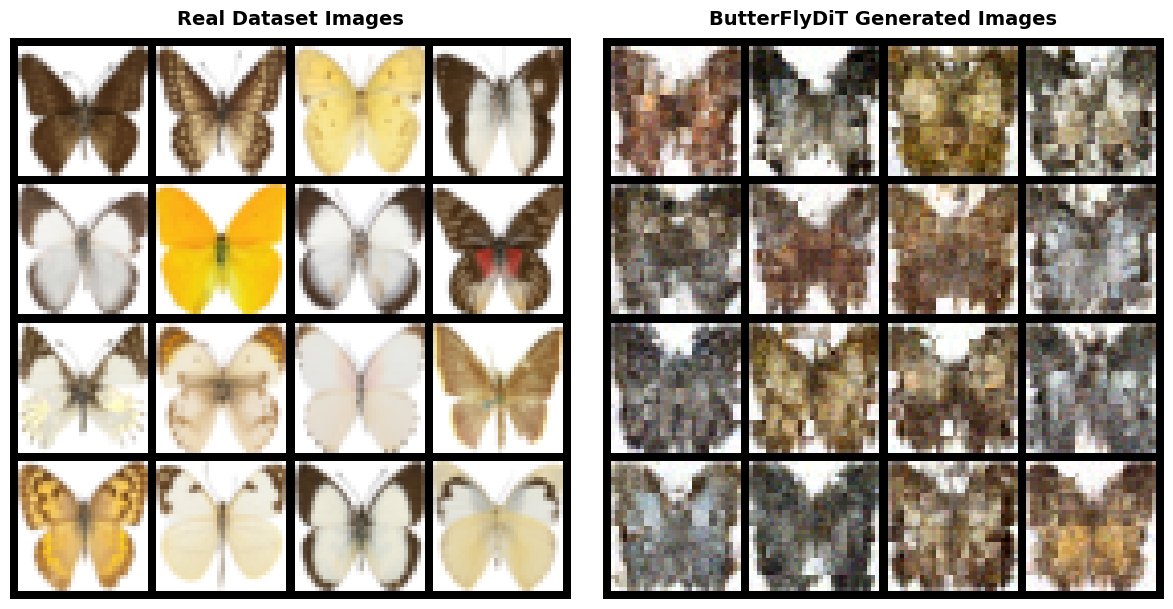

In [ ]:
# Initialize FID metric (removed subset_size as FID does not use subsets)
fid_metric = FrechetInceptionDistance(feature=64).to(device)

@torch.no_grad()
def sample(model, num_samples=16):
    model.eval()
    x = torch.randn(num_samples, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
    for i in reversed(range(TIMESTEPS)):
        t = torch.full((num_samples,), i, device=device, dtype=torch.long)
        predicted_noise = model(x, t)

        a_t = alpha[i]
        a_bar_t = alpha_bar[i]
        beta_t = beta[i]

        mean = (1 / torch.sqrt(a_t)) * (x - ((1 - a_t) / torch.sqrt(1 - a_bar_t)) * predicted_noise)
        if i > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta_t) * noise
        else:
            x = mean
    return x

print("Sampling 64 images for evaluation...")
# 1. Generate raw model outputs in [-1, 1] range
raw_generated = sample(model, num_samples=64)
print(raw_generated.min(), raw_generated.max())

# 2. Get real images in [-1, 1] range from dataloader
raw_real = next(iter(dataloader))[0][:64].to(device)

# 3. Convert directly from [-1, 1] -> uint8 [0, 255] for FID Metric
real_uint8 = ((raw_real.clamp(-1, 1) + 1) / 2 * 255).to(torch.uint8)
generated_uint8 = ((raw_generated.clamp(-1, 1) + 1) / 2 * 255).to(torch.uint8)

# 4. Compute FID Metric
fid_metric.update(real_uint8, real=True)
fid_metric.update(generated_uint8, real=False)
fid_score = fid_metric.compute()

print("="*50)
print(f"FID Score: {fid_score.item():.4f} (Lower = Better)")
print("="*50)

# 5. Convert to float [0, 1] range ONLY for Matplotlib plotting grid
real_grid_imgs = (raw_real[:16].clamp(-1, 1) + 1) / 2
gen_grid_imgs = (raw_generated[:16].clamp(-1, 1) + 1) / 2

real_grid = make_grid(real_grid_imgs, nrow=4).cpu().permute(1, 2, 0)
generated_grid = make_grid(gen_grid_imgs, nrow=4).cpu().permute(1, 2, 0)

# Plot Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(real_grid)
axes[0].set_title("Real Dataset Images", fontsize=14, fontweight="bold", pad=10)
axes[0].axis("off")

axes[1].imshow(generated_grid)
axes[1].set_title("ButterFlyDiT Generated Images", fontsize=14, fontweight="bold", pad=10)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Let's see one sample being generated

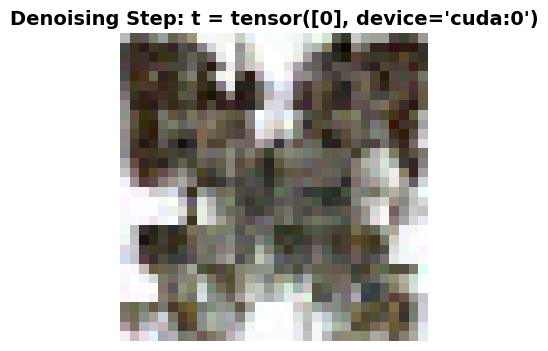

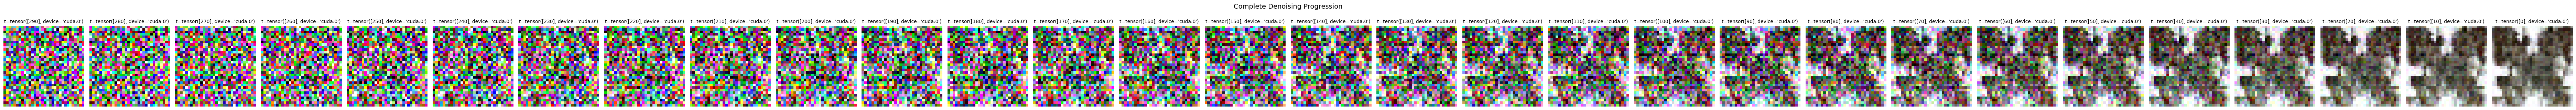

In [ ]:
def plot_summary_grid(images, timesteps):
    """Plots a static grid showing the progression from noise to image."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(n * 2.5, 3))
    for i, (img, t) in enumerate(zip(images, timesteps)):
        axes[i].imshow(img)
        axes[i].set_title(f"t={t}", fontsize=10)
        axes[i].axis("off")
    plt.suptitle("Complete Denoising Progression", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

model.eval()
x = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
history_images = []
history_timesteps = []
for i in reversed(range(TIMESTEPS)):
    t = torch.full((1,), i, device=device, dtype=torch.long)
    predicted_noise = model(x, t)

    a_t = alpha[i]
    a_bar_t = alpha_bar[i]
    beta_t = beta[i]

    mean = (1 / torch.sqrt(a_t)) * (x - ((1 - a_t) / torch.sqrt(1 - a_bar_t)) * predicted_noise)
    if i > 0:
        noise = torch.randn_like(x)
        x = mean + torch.sqrt(beta_t) * noise
    else:
        x = mean

    # 3. Live Plot Update in Colab
    if t % 10 == 0 or t == 0:
        # Convert tensor from [-1, 1] or arbitrary range to plottable [0, 1] RGB image
        img = x.squeeze(0).permute(1, 2, 0).cpu()
        img = torch.clamp((img + 1.0) / 2.0, 0.0, 1.0).detach().numpy()

        history_images.append(img)
        history_timesteps.append(t)

        # --- Colab Live Rendering Trick ---
        clear_output(wait=True)  # Wait=True prevents flickering
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"Denoising Step: t = {t}", fontsize=14, fontweight="bold")
        ax.axis("off")
        plt.show()
        plt.close(fig)

# 4. Display a final step-by-step summary grid
plot_summary_grid(history_images, history_timesteps)